# Basic Reflection

Port of the LangGraph [Reflection](https://langchain-ai.github.io/langgraph/tutorials/reflection/reflection/) agent pattern to LangGraph4j.

Related to [#8](https://github.com/langgraph4j/langgraph4j/issues/8).

## Agentic Architecture

```
START → generate → reflect ──► (continue) → generate
              ↑                 │
              └─────────────────┘
                                └──► END
```

| Node | Role |
|------|------|
| `generate` | Produce (or revise) a draft answer |
| `reflect` | Critique the latest draft and suggest improvements |

The loop stops after a fixed number of generate/reflect rounds (`MAX_ROUNDS`).

Modes:

1. **Stub** — deterministic draft/critique, no API key  
2. **LLM** — LangChain4j `AiServices` writer + critic (`OPENAI_API_KEY`)


In [1]:
var userHomeDir = System.getProperty("user.home");
var localRespoUrl = "file://" + userHomeDir + "/.m2/repository/";
var langchain4jVersion = "1.18.1";
var langchain4jbeta = "1.18.1-beta28";
var langgraph4jVersion = "1.8.26";


Remove installed package from Jupyter cache


In [2]:
%%bash 
rm -rf \{userHomeDir}/Library/Jupyter/kernels/rapaio-jupyter-kernel/mima_cache/org/bsc/langgraph4j


Add local Maven repo and resolve dependencies


In [3]:
%dependency /add-repo local \{localRespoUrl} release|never snapshot|always
// %dependency /list-repos
%dependency /add org.slf4j:slf4j-jdk14:2.0.9
%dependency /add org.bsc.langgraph4j:langgraph4j-langchain4j:\{langgraph4jVersion}
%dependency /add dev.langchain4j:langchain4j-open-ai:\{langchain4jVersion}
%dependency /add net.sourceforge.plantuml:plantuml-mit:1.2024.8

%dependency /resolve


Repository local url: file:///Users/bsorrentino/.m2/repository/ added.
Adding dependency org.slf4j:slf4j-jdk14:2.0.9
Adding dependency org.bsc.langgraph4j:langgraph4j-langchain4j:1.8.26
Adding dependency dev.langchain4j:langchain4j-open-ai:1.18.1
Adding dependency net.sourceforge.plantuml:plantuml-mit:1.2024.8
Solving dependencies
Resolved artifacts count: 20
Add to classpath: /Users/bsorrentino/Library/Jupyter/kernels/rapaio-jupyter-kernel/mima_cache/org/slf4j/slf4j-jdk14/2.0.9/slf4j-jdk14-2.0.9.jar
Add to classpath: /Users/bsorrentino/Library/Jupyter/kernels/rapaio-jupyter-kernel/mima_cache/org/slf4j/slf4j-api/2.0.9/slf4j-api-2.0.9.jar
Add to classpath: /Users/bsorrentino/Library/Jupyter/kernels/rapaio-jupyter-kernel/mima_cache/org/bsc/langgraph4j/langgraph4j-langchain4j/1.8.26/langgraph4j-langchain4j-1.8.26.jar
Add to classpath: /Users/bsorrentino/Library/Jupyter/kernels/rapaio-jupyter-kernel/mima_cache/dev/langchain4j/langchain4j/1.18.1/langchain4j-1.18.1.jar
Add to classpath: /Use

**Initialize Logger**


In [4]:
try( var file = new java.io.FileInputStream("./logging.properties")) {
    java.util.logging.LogManager.getLogManager().readConfiguration( file );
}

var log = org.slf4j.LoggerFactory.getLogger("BasicReflection");


**Utility to render graph representation in PlantUML**


In [5]:
import net.sourceforge.plantuml.SourceStringReader;
import net.sourceforge.plantuml.FileFormatOption;
import net.sourceforge.plantuml.FileFormat;

java.awt.Image plantUML2PNG( String code ) throws IOException { 
    var reader = new SourceStringReader(code);

    try(var imageOutStream = new java.io.ByteArrayOutputStream()) {

        var description = reader.outputImage( imageOutStream, 0, new FileFormatOption(FileFormat.PNG));

        var imageInStream = new java.io.ByteArrayInputStream(  imageOutStream.toByteArray() );

        return javax.imageio.ImageIO.read( imageInStream );

    }
}


## 1. Define the State

Message list accumulates: user topic → draft → critique → revised draft → …


In [6]:
import org.bsc.langgraph4j.prebuilt.MessagesState;
import org.bsc.langgraph4j.state.Channel;

import java.util.List;
import java.util.Map;

final int MAX_ROUNDS = 2;

class ReflectionState extends MessagesState<String> {

    public static final Map<String, Channel<?>> SCHEMA = MessagesState.SCHEMA;

    public ReflectionState(Map<String, Object> initData) {
        super(initData);
    }

    public String topic() {
        var msgs = messages();
        return msgs.isEmpty() ? "" : msgs.get(0);
    }

    public long draftCount() {
        return messages().stream().filter(m -> m.startsWith("DRAFT:")).count();
    }

    public String lastMessageOrEmpty() {
        return lastMessage().orElse("");
    }
}


## 2. Routing


In [7]:
import org.bsc.langgraph4j.action.EdgeAction;

EdgeAction<ReflectionState> shouldContinue = state ->
        state.draftCount() >= MAX_ROUNDS ? "end" : "continue";


## 3. Stub mode (no API key)


In [8]:
import org.bsc.langgraph4j.action.NodeAction;

class StubGenerateNode implements NodeAction<ReflectionState> {
    @Override
    public Map<String, Object> apply(ReflectionState state) {
        var round = state.draftCount() + 1;
        var critique = state.messages().stream()
                .filter(m -> m.startsWith("CRITIQUE:"))
                .reduce((a, b) -> b)
                .orElse("");
        var draft = critique.isBlank()
                ? "DRAFT: (round " + round + ") An initial essay about: " + state.topic()
                : "DRAFT: (round " + round + ") Revised essay about: " + state.topic()
                  + " | addressing: " + critique.substring("CRITIQUE:".length()).trim();
        log.info("stub generate: {}", draft);
        return Map.of("messages", draft);
    }
}

class StubReflectNode implements NodeAction<ReflectionState> {
    @Override
    public Map<String, Object> apply(ReflectionState state) {
        var draft = state.lastMessageOrEmpty();
        var critique = "CRITIQUE: Add a concrete example and a clearer conclusion for: " + draft;
        log.info("stub reflect: {}", critique);
        return Map.of("messages", critique);
    }
}


### Build / visualize / run stub graph


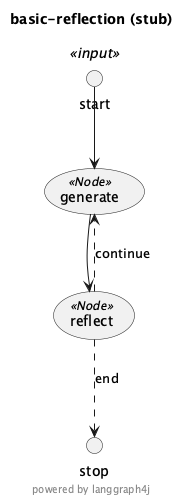

START 


In [9]:
import org.bsc.langgraph4j.StateGraph;
import org.bsc.langgraph4j.GraphRepresentation;
import static org.bsc.langgraph4j.action.AsyncNodeAction.node_async;
import static org.bsc.langgraph4j.action.AsyncEdgeAction.edge_async;
import static org.bsc.langgraph4j.StateGraph.START;
import static org.bsc.langgraph4j.StateGraph.END;

var stubWorkflow = new StateGraph<>(ReflectionState.SCHEMA, ReflectionState::new)
        .addNode("generate", node_async(new StubGenerateNode()))
        .addNode("reflect", node_async(new StubReflectNode()))
        .addEdge(START, "generate")
        .addEdge("generate", "reflect")
        .addConditionalEdges("reflect", edge_async(shouldContinue), Map.of(
                "continue", "generate",
                "end", END
        ));

var stubApp = stubWorkflow.compile();

var representation = stubWorkflow.getGraph(GraphRepresentation.Type.PLANTUML, "basic-reflection (stub)", false);
display(plantUML2PNG(representation.getContent()));

var stubInput = Map.<String,Object>of(
        "messages", "Write a short essay about the benefits of journaling."
);
for (var event : stubApp.stream(stubInput)) {
    log.info("STUB STEP: {}", event);
}


## 4. LLM mode (LangChain4j AiServices)

Requires `OPENAI_API_KEY`. Two roles:

* **Writer** — generate/revise the essay  
* **Critic** — reflect on the latest draft


In [10]:
import dev.langchain4j.model.chat.ChatModel;
import dev.langchain4j.model.openai.OpenAiChatModel;
import dev.langchain4j.service.AiServices;
import dev.langchain4j.service.SystemMessage;
import dev.langchain4j.service.UserMessage;

import java.time.Duration;
import java.util.stream.Collectors;

var openAiKey = System.getenv("OPENAI_API_KEY");
var llmEnabled = openAiKey != null && !openAiKey.isBlank();
log.info("LLM mode enabled: {}", llmEnabled);

ChatModel chatModel = null;
if (llmEnabled) {
    chatModel = OpenAiChatModel.builder()
            .apiKey(openAiKey)
            .modelName("gpt-4o-mini")
            .timeout(Duration.ofMinutes(2))
            .logRequests(true)
            .logResponses(true)
            .maxRetries(2)
            .temperature(0.2)
            .maxTokens(1500)
            .build();
}

interface WriterService {
    @SystemMessage("You are an essay writer. Produce a concise essay draft. "
            + "If critique feedback is provided, revise the previous draft accordingly. "
            + "Return only the essay text.")
    String write(@UserMessage String prompt);
}

interface CriticService {
    @SystemMessage("You are a writing critic. Give brief, actionable critique "
            + "(structure, clarity, examples, conclusion). Return only the critique.")
    String critique(@UserMessage String draft);
}

String conversationContext(ReflectionState state) {
    return state.messages().stream().collect(Collectors.joining("\n"));
}


In [11]:
class LlmGenerateNode implements NodeAction<ReflectionState> {
    private final WriterService writer;

    LlmGenerateNode(ChatModel model) {
        this.writer = AiServices.create(WriterService.class, model);
    }

    @Override
    public Map<String, Object> apply(ReflectionState state) {
        var prompt = "Topic / conversation so far:\n" + conversationContext(state)
                + "\n\nWrite or revise the essay now.";
        var essay = writer.write(prompt);
        var draft = "DRAFT: " + essay;
        log.info("llm generate round={}", state.draftCount() + 1);
        return Map.of("messages", draft);
    }
}

class LlmReflectNode implements NodeAction<ReflectionState> {
    private final CriticService critic;

    LlmReflectNode(ChatModel model) {
        this.critic = AiServices.create(CriticService.class, model);
    }

    @Override
    public Map<String, Object> apply(ReflectionState state) {
        var draft = state.lastMessageOrEmpty();
        var text = draft.startsWith("DRAFT:") ? draft.substring("DRAFT:".length()).trim() : draft;
        var critique = critic.critique(text);
        log.info("llm reflect");
        return Map.of("messages", "CRITIQUE: " + critique);
    }
}


### Build / run LLM graph

Skipped when `OPENAI_API_KEY` is unset.


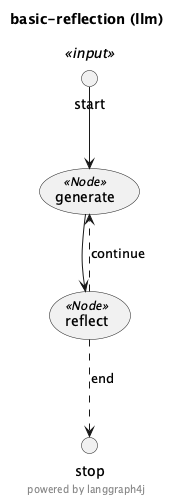

START 


In [12]:
if (!llmEnabled) {
    log.warn("Skipping LLM graph — set OPENAI_API_KEY to enable.");
} else {
    var llmWorkflow = new StateGraph<>(ReflectionState.SCHEMA, ReflectionState::new)
            .addNode("generate", node_async(new LlmGenerateNode(chatModel)))
            .addNode("reflect", node_async(new LlmReflectNode(chatModel)))
            .addEdge(START, "generate")
            .addEdge("generate", "reflect")
            .addConditionalEdges("reflect", edge_async(shouldContinue), Map.of(
                    "continue", "generate",
                    "end", END
            ));

    var llmApp = llmWorkflow.compile();
    var llmRepresentation = llmWorkflow.getGraph(
            GraphRepresentation.Type.PLANTUML, "basic-reflection (llm)", false);
    display(plantUML2PNG(llmRepresentation.getContent()));

    var llmInput = Map.<String,Object>of(
            "messages", "Write a short essay about the benefits of journaling."
    );
    for (var event : llmApp.stream(llmInput)) {
        log.info("LLM STEP: {}", event);
    }
}


## 5. Next steps

* Tune `MAX_ROUNDS` or stop when the critic says the draft is good enough  
* Persist with `MemorySaver` (`persistence.ipynb`)  
* More [#8](https://github.com/langgraph4j/langgraph4j/issues/8) ports: Self-RAG, Reflexion, Plan-and-Execute
